In [ ]:
import pandas as pd
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from qiskit.circuit.library import pauli_feature_map
from qiskit.quantum_info import SparsePauliOp, Statevector


import os
from multiprocessing import Process


os.makedirs("../results/experiment_15_v3", exist_ok=True)

In [6]:
dataset = pd.read_csv("../dataset/riemann_features.csv")

features = pd.read_csv("../results/data_analysis/selected_features.csv")["feature"].tolist()

X = dataset.drop(columns=["distance"])
y = dataset["distance"]

X = X[:2000]
y = y[:2000]

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1600, 94) (1600,)
(400, 94) (400,)


# Classical SVR

In [8]:
def run_classical_experiment():
    results = []

    param_grid = {
        "svr__C": [0.1, 1, 5, 10],
        "svr__epsilon": [0.001, 0.01, 0.1, 0.5],
        "svr__gamma": ["scale", 0.01, 0.1, 1.0]
    }

    n_features = [i for i in range(1, 11)]

    for n in n_features:
        print(f"Running experiment for group: Rank Aggregation with {n} features")

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        pipeline = Pipeline([
            ("scaler", MinMaxScaler()),
            ("svr", SVR(kernel="rbf"))
        ])

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
            n_jobs=-1
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "MSE": mse,
            "R2": r2,
            "Best C": grid.best_params_["svr__C"],
            "Best epsilon": grid.best_params_["svr__epsilon"],
            "Best gamma": grid.best_params_["svr__gamma"],
            "Features": n
        })

    results_df = pd.DataFrame(results).sort_values("MSE").reset_index(drop=True)
    print(results_df)
    results_df.to_csv("../results/experiment_15_v3/classical_experiment_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("Features")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["Features"], plot_df["MSE"], 'b-o')
    plt.xlabel("Número de Características")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Características (Clássico RBF)")
    plt.xticks(n_features)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Running experiment for group: Rank Aggregation with 1 features
Running experiment for group: Rank Aggregation with 2 features
Running experiment for group: Rank Aggregation with 3 features
Running experiment for group: Rank Aggregation with 4 features
Running experiment for group: Rank Aggregation with 5 features
Running experiment for group: Rank Aggregation with 6 features
Running experiment for group: Rank Aggregation with 7 features
Running experiment for group: Rank Aggregation with 8 features
Running experiment for group: Rank Aggregation with 9 features
Running experiment for group: Rank Aggregation with 10 features
        MSE        R2  Best C  Best epsilon Best gamma  Features
0  0.003348  0.958818    10.0         0.001      scale         9
1  0.004294  0.947179    10.0         0.001      scale         6
2  0.005017  0.938285     5.0         0.001      scale        10
3  0.005018  0.938264    10.0         0.001      scale         8
4  0.005321  0.934541    10.0         0.001 

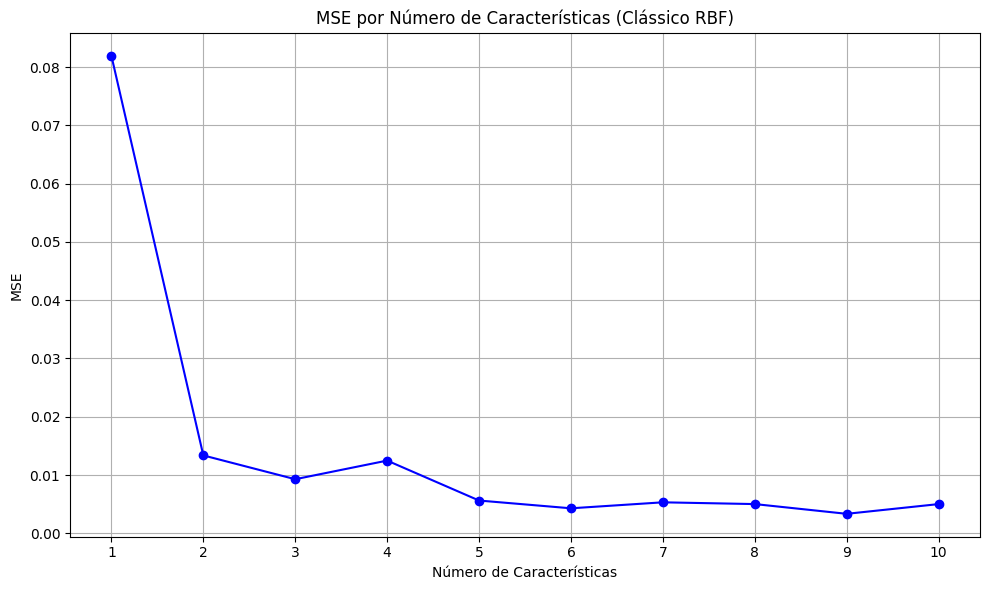

In [9]:
run_classical_experiment()

# Quantum SVR - DoubleAngleEntangledFeatureMap

In [10]:
def feature_map(x, wires, rotation_first="X", rotation_second="Y"):
    qml.AngleEmbedding(x, wires=wires, rotation=rotation_first)
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )
    qml.AngleEmbedding(x, wires=wires, rotation=rotation_second)


def make_simple_kernel(n_qubits, rotation_first="X", rotation_second="Y"):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)
        feature_map(x1, wires=wires, rotation_first=rotation_first, rotation_second=rotation_second)
        qml.adjoint(feature_map)(x2, wires=wires, rotation_first=rotation_first, rotation_second=rotation_second)
        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn

## DoubleAngleEntangledFeatureMap Circuit

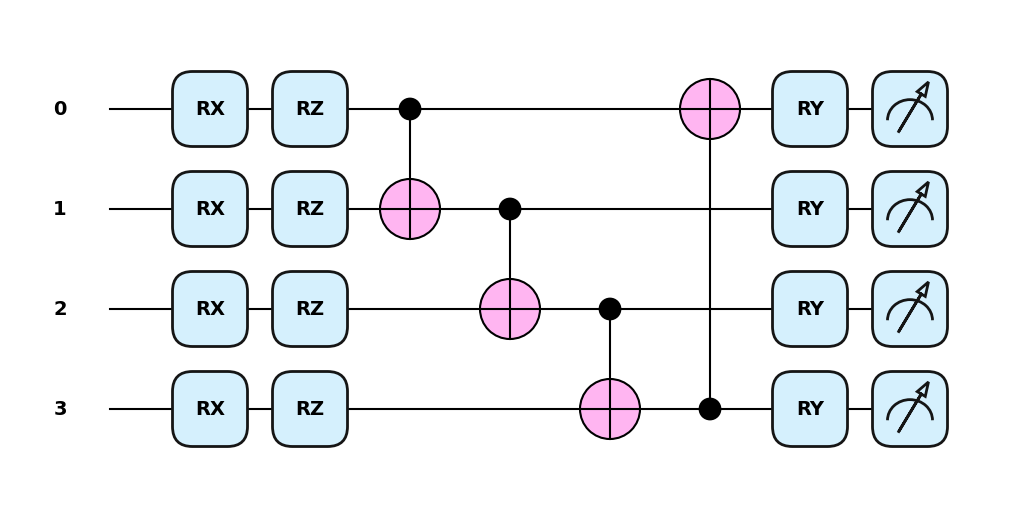

In [11]:
n_qubits = 4
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def encoding_circuit(x):
    feature_map(x, wires=range(n_qubits))
    return qml.state()


fig, ax = qml.draw_mpl(
    encoding_circuit,
    style="pennylane",
    level="device"
)(x_example)

plt.savefig("../results/experiment_15_v3/angle_entangled_feature_map.png", dpi=160, bbox_inches='tight')
plt.show()

In [12]:
def fourier_feature_map(x, wires):
    for i in range(len(wires)):
        qml.RX(x[i], wires=wires[i])
        qml.RZ(x[i], wires=wires[i])

    for i in range(len(wires)-1):
        qml.CNOT(wires=[wires[i], wires[i+1]])

    for i in range(len(wires)):
        qml.RZ(np.sin(x[i]) + np.cos(2*x[i]), wires=wires[i])


def make_fourier_kernel(n_qubits):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)

        fourier_feature_map(x1, wires=wires)
        qml.adjoint(fourier_feature_map)(x2, wires=wires)

        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn

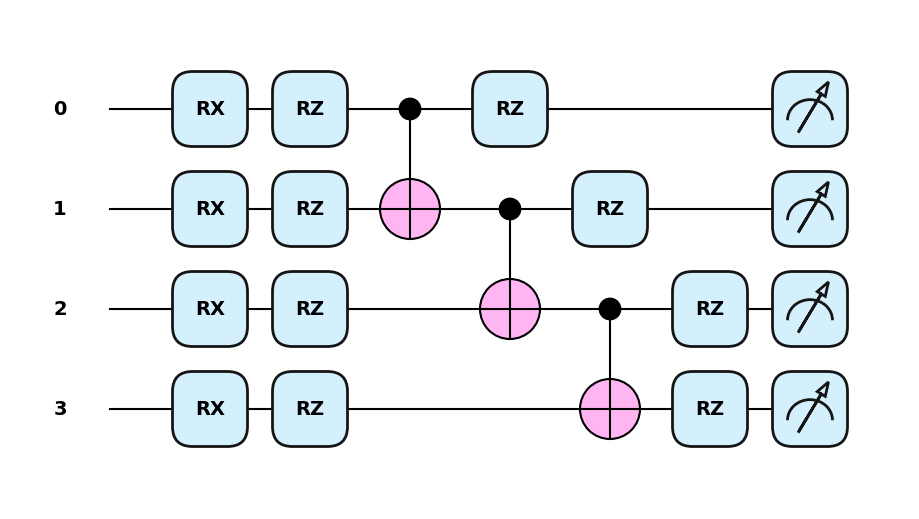

In [13]:
n_qubits = 4
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def encoding_circuit(x):
    fourier_feature_map(x, wires=range(n_qubits))
    return qml.state()


fig, ax = qml.draw_mpl(
    encoding_circuit,
    style="pennylane",
    level="device"
)(x_example)

plt.savefig("../results/experiment_15_v3/fourier_feature_map.png", dpi=160, bbox_inches='tight')
plt.show()

In [ ]:
def run_simple_experiment():
    results = []
    n_qubits = list(range(2, 11))
    kernels = {f"{n}_XY": (make_simple_kernel(n, rotation_first="X", rotation_second="Y"), n) for n in n_qubits}

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, MSE: {mse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "n_qubits": n,
            "mse": mse,
            "r2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })

    results_df = pd.DataFrame(results)
    print(results_df)
    results_df\
        .sort_values("mse")\
        .to_csv("../results/experiment_15_v3/simple_experiment_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("n_qubits")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["n_qubits"], plot_df["mse"], 'g-o')
    plt.xlabel("Número de Qubits")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Qubits (Angle Encoding)")
    plt.xticks(n_qubits)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def riemann_advanced_data_map(x):
    x = np.asarray(x)

    x_safe = x + 1e-8

    theta_like = np.sum(x_safe * np.log(x_safe))
    val = np.cos(theta_like)

    for i in range(len(x) - 1):
        val += 0.3 * np.cos(x[i] - x[i+1])
        val += 0.3 * np.sin(x[i] * x[i+1])

    return val


def preproc_rbf_s1(X: np.ndarray) -> np.ndarray:
    return np.exp(-(X ** 2) / 2.0)


def full_pauli_labels(n_qubits: int):
    from itertools import product
    alphabet = ["I", "X", "Y", "Z"]
    return ["".join(p) for p in product(alphabet, repeat=n_qubits)]


def build_pauli_matrix_full(
    X: np.ndarray,
    N_QUBITS: int
) -> np.ndarray:
    n_samples, n = X.shape

    labels = full_pauli_labels(N_QUBITS)
    ops = [SparsePauliOp(lab[::-1]) for lab in labels]

    fm = pauli_feature_map(
        feature_dimension=n,
        paulis=["Z", "ZZ"],
        entanglement="full",
        reps=1,
        data_map_func=riemann_advanced_data_map,
    )

    A = np.zeros((n_samples, len(ops)), dtype=float)

    for i, x in enumerate(X):
        bound = fm.assign_parameters(x, inplace=False)
        psi = Statevector.from_instruction(bound)
        for j, op in enumerate(ops):
            A[i, j] = float(np.real(psi.expectation_value(op)))

    return A


def run_quantum_experiment_pauli_feature_map():
    results = []
    n_features = [2, 3, 4, 5, 6, 7, 8, 9, 10]

    param_grid = {
        "C": [0.1, 1, 5, 10],
        "epsilon": [0.001, 0.01, 0.1, 0.5]
    }

    for n in n_features:
        print(f"Running quantum experiment with {n} features using Pauli feature map")

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()
        X_train_subset = preproc_rbf_s1(X_train_subset)
        X_test_subset = preproc_rbf_s1(X_test_subset)

        A_train = build_pauli_matrix_full(X_train_subset, N_QUBITS=n)
        A_test = build_pauli_matrix_full(X_test_subset, N_QUBITS=n)

        kernel_matrix = A_train @ A_train.T
        kernel_matrix_test = A_test @ A_train.T

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel="precomputed"))
        ])

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
            n_jobs=-1
        )

        grid.fit(kernel_matrix, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(kernel_matrix_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print("Results for {} features: MSE = {:.4f}, R2 = {:.4f}".format(n, mse, r2))

        results.append({
            "N Features": n,
            "MSE": mse,
            "R2": r2,
            "Best C": grid.best_params_["C"],
            "Best epsilon": grid.best_params_["epsilon"],
        })

    results_df = pd.DataFrame(results).sort_values("MSE").reset_index(drop=True)
    print(results_df)
    results_df.to_csv("../results/experiment_15_v3/quantum_pauli_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("N Features")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["N Features"], plot_df["MSE"], 'r-o')
    plt.xlabel("Número de Características")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Características (Quantum Pauli Feature Map)")
    plt.xticks(n_features)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def run_fourier_experiment():
    results = []
    n_qubits = list(range(2, 11))
    kernels = {f"{n}_Fourier": (make_fourier_kernel(n), n) for n in n_qubits}

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        rmse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, RMSE: {rmse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "n_qubits": n,
            "rmse": rmse,
            "r2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })

    results_df = pd.DataFrame(results)
    print(results_df)
    results_df\
        .sort_values("rmse")\
        .to_csv("../results/experiment_15_v3/fourier_experiment_results.csv", index=False)

    plot_df = pd.DataFrame(results).sort_values("n_qubits")
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df["n_qubits"], plot_df["rmse"], 'm-o')
    plt.xlabel("Número de Qubits")
    plt.ylabel("MSE")
    plt.title("MSE por Número de Qubits (Fourier Kernel)")
    plt.xticks(n_qubits)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
p_simple_process  = Process(target=run_simple_experiment)
p_pauli_process   = Process(target=run_quantum_experiment_pauli_feature_map)
p_fourier_process = Process(target=run_fourier_experiment)

p_simple_process.start()
p_pauli_process.start()
p_fourier_process.start()
p_simple_process.join()
p_pauli_process.join()
p_fourier_process.join()

Running kernel 6_simple
Running kernel 1_enhanced
Running kernel 4_fourier
Kernel: 1_enhanced, RMSE: 0.2864, R^2: -0.0093
Running kernel 2_enhanced
Kernel: 4_fourier, RMSE: 0.1294, R^2: 0.7942
Running kernel 6_fourier
Kernel: 2_enhanced, RMSE: 0.1705, R^2: 0.6423
Running kernel 3_enhanced
Kernel: 6_simple, RMSE: 0.0890, R^2: 0.9026
Running kernel 8_simple
Kernel: 3_enhanced, RMSE: 0.1279, R^2: 0.7987
Running kernel 4_enhanced
Kernel: 6_fourier, RMSE: 0.0781, R^2: 0.9250
Running kernel 8_fourier
Kernel: 4_enhanced, RMSE: 0.1389, R^2: 0.7628
Running kernel 5_enhanced
Kernel: 8_simple, RMSE: 0.0822, R^2: 0.9169
Running kernel 9_simple
Kernel: 8_fourier, RMSE: 0.0730, R^2: 0.9344
Running kernel 9_fourier
Kernel: 5_enhanced, RMSE: 0.0789, R^2: 0.9234
Running kernel 6_enhanced
Kernel: 9_simple, RMSE: 0.0659, R^2: 0.9465
Running kernel 10_simple
Kernel: 9_fourier, RMSE: 0.0619, R^2: 0.9529
Running kernel 10_fourier
Kernel: 6_enhanced, RMSE: 0.0754, R^2: 0.9300
Running kernel 8_enhanced
Kernel

In [ ]:
def plot_combined_results():
    classical_df = pd.read_csv("../results/experiment_15_v3/classical_experiment_results.csv")
    pauli_df = pd.read_csv("../results/experiment_15_v3/quantum_pauli_results.csv")
    simple_df = pd.read_csv("../results/experiment_15_v3/simple_experiment_results.csv")
    fourier_df = pd.read_csv("../results/experiment_15_v3/fourier_experiment_results.csv")

    classical_df = classical_df.sort_values("Features")
    pauli_df = pauli_df.sort_values("N Features")
    simple_df = simple_df.sort_values("n_qubits")
    fourier_df = fourier_df.sort_values("n_qubits")

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

    axes[0].plot(classical_df["Features"], classical_df["MSE"], 'b-o')
    axes[0].set_title("Clássico (RBF)")
    axes[0].set_xlabel("Número de Características")
    axes[0].set_ylabel("MSE")
    axes[0].set_xticks(range(1, 11))
    axes[0].grid(True)

    axes[1].plot(pauli_df["N Features"], pauli_df["MSE"], 'r-o')
    axes[1].set_title("Pauli Feature Map")
    axes[1].set_xlabel("Número de Características")
    axes[1].set_xticks(range(2, 11))
    axes[1].grid(True)

    axes[2].plot(simple_df["n_qubits"], simple_df["mse"], 'g-o')
    axes[2].set_title("Angle Encoding")
    axes[2].set_xlabel("Número de Qubits")
    axes[2].set_xticks(range(2, 11))
    axes[2].grid(True)

    axes[3].plot(fourier_df["n_qubits"], fourier_df["rmse"], 'm-o')
    axes[3].set_title("Fourier Kernel")
    axes[3].set_xlabel("Número de Qubits")
    axes[3].set_xticks(range(2, 11))
    axes[3].grid(True)

    fig.suptitle("MSE por Número de Características/Qubits", fontsize=14)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(classical_df["Features"], classical_df["MSE"], 'b-o', label="Clássico (RBF)")
    plt.plot(pauli_df["N Features"], pauli_df["MSE"], 'r-s', label="Pauli Feature Map")
    plt.plot(simple_df["n_qubits"], simple_df["mse"], 'g-^', label="Angle Encoding")
    plt.plot(fourier_df["n_qubits"], fourier_df["rmse"], 'm-D', label="Fourier Kernel")
    plt.xlabel("Número de Características/Qubits")
    plt.ylabel("MSE")
    plt.title("Comparação de MSE entre Feature Maps")
    plt.xticks(range(1, 11))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_combined_results()